Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[INFO] Kullanılan cihaz: cuda
[INFO] '/content/drive/MyDrive/Colab Notebooks/cnn-proje/dataset/kendi_veri_seti.npz' bulundu, önbellekten yükleniyor...


/tmp/ipykernel_820/1935902761.py:180: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  renkler = plt.cm.get_cmap('tab10', len(isimler)).colors



[INFO] Eğitim başlıyor...

  Epoch [  1/30]  Kayıp: 1.7043  |  Val: %60.0  ★ En iyi!
  Epoch [ 10/30]  Kayıp: 0.4497  |  Val: %89.2  
  Epoch [ 20/30]  Kayıp: 0.2047  |  Val: %95.6  
  Epoch [ 30/30]  Kayıp: 0.1432  |  Val: %96.4  

✅ Eğitim Bitti! Google Drive'ına kaydedilen dosyalar:
   /content/drive/MyDrive/Colab Notebooks/cnn-proje/model2/cnn_model2.pth
   /content/drive/MyDrive/Colab Notebooks/cnn-proje/model2/isimler.pkl

▶ Lütfen model2 klasörünü Drive'dan bilgisayarına indir ve Streamlit uygulamanın yanına koy.


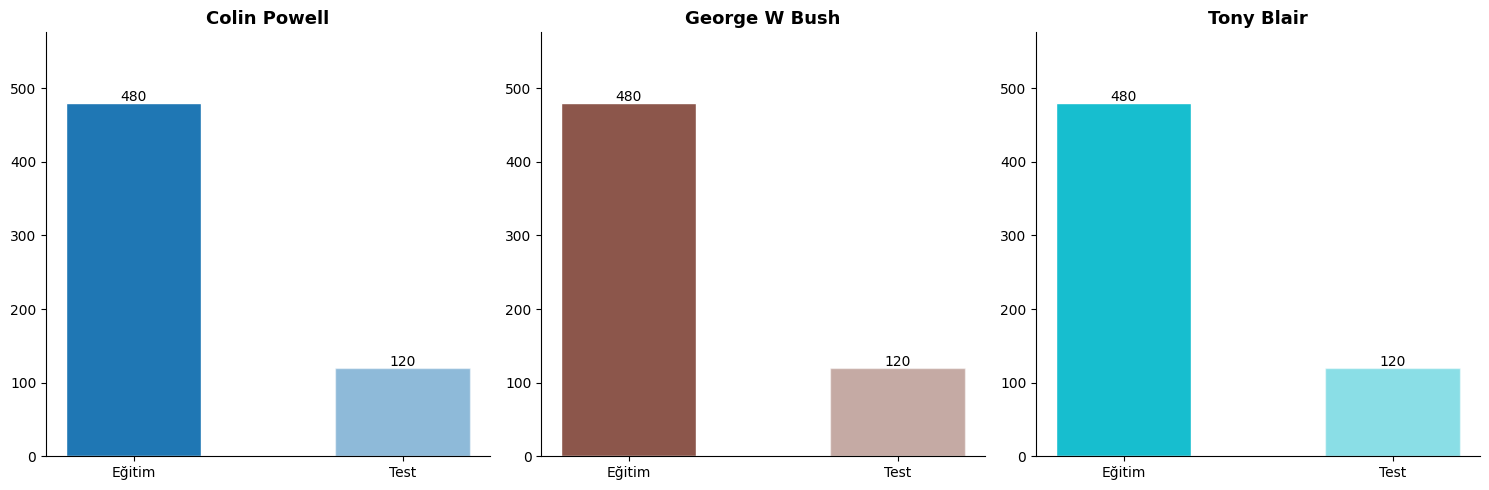

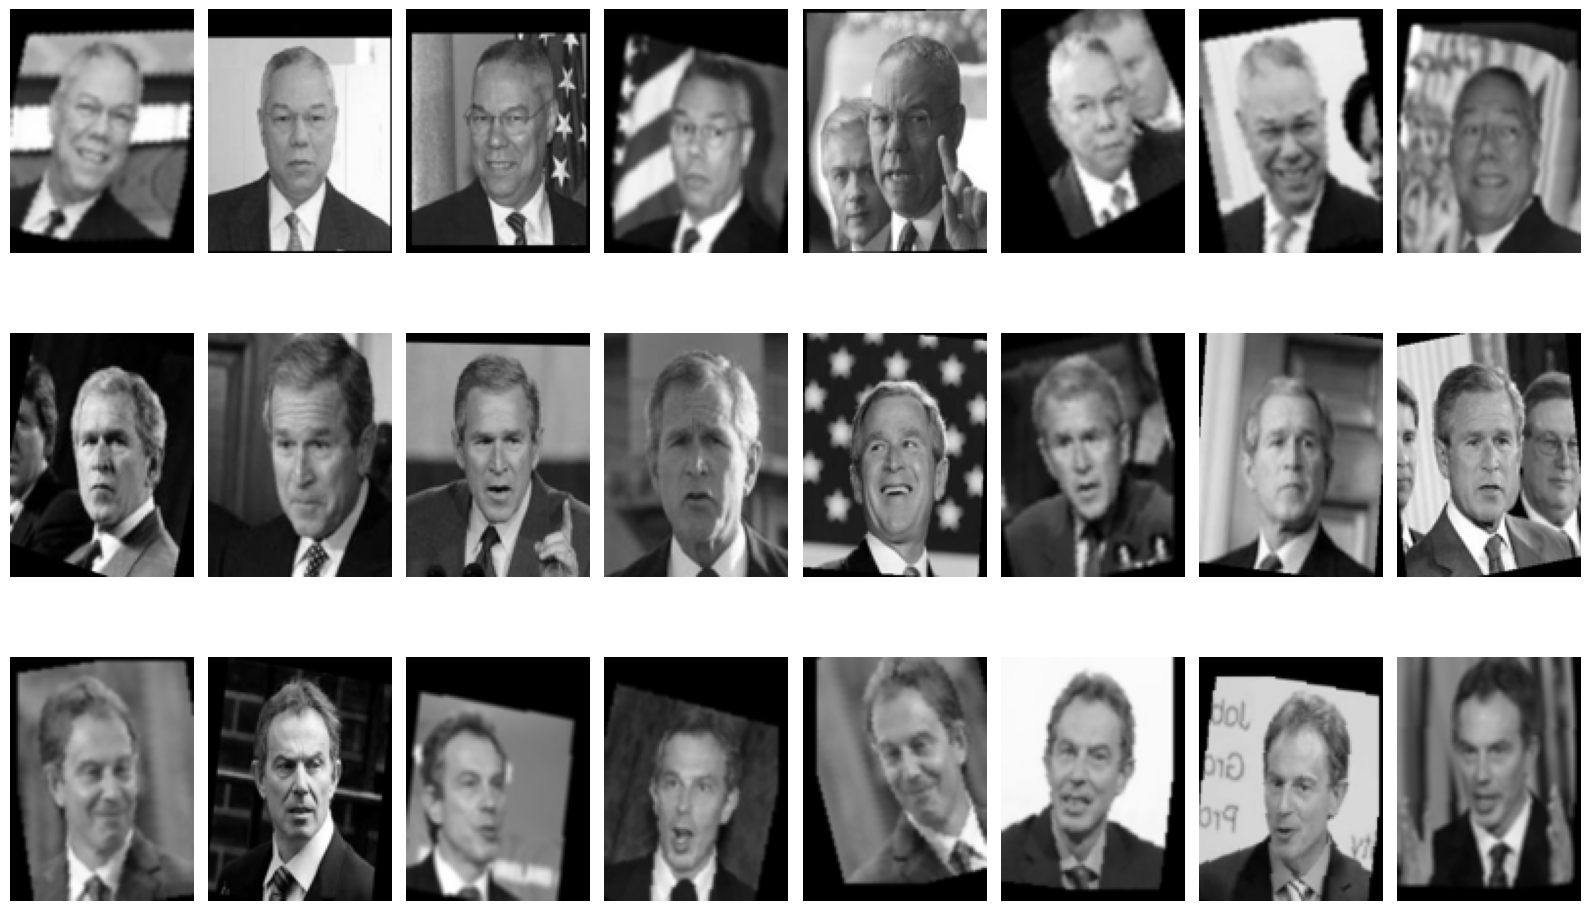

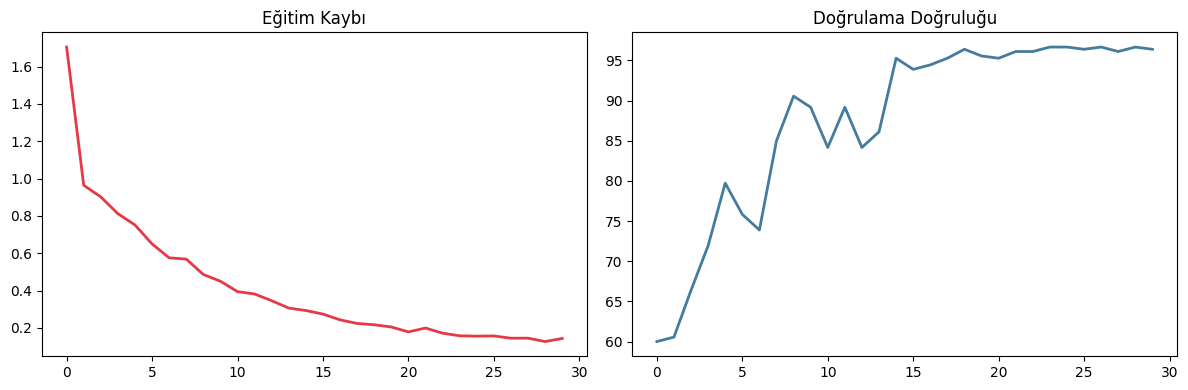

In [1]:
"""
=============================================================
  Yüz Tanıma CNN — Google Colab & Drive Uyumlu Eğitim Scripti
  Google Drive'daki klasörleri okur, eğitir ve modeli Drive'a kaydeder.
=============================================================
"""

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.model_selection import train_test_split
import pickle
import matplotlib.pyplot as plt
from PIL import Image

# ── 1. GOOGLE DRIVE BAĞLANTISI ──
from google.colab import drive
drive.mount('/content/drive')

# Drive'da oluşturduğumuz ana klasörün yolu
PROJE_YOLU = '/content/drive/MyDrive/Colab Notebooks/cnn-proje'
ANA_KLASOR = f"{PROJE_YOLU}/kendi_datasetim"
MODEL_KLASORU = f"{PROJE_YOLU}/model2"
DATASET_KLASORU = f"{PROJE_YOLU}/dataset"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n[INFO] Kullanılan cihaz: {device}")
if device.type == "cpu":
    print("⚠️ UYARI: Colab'da GPU aktif değil! Menüden 'Çalışma zamanı türünü değiştir' deyip GPU'yu seçin.")

# ──────────────────────────────────────────────────────────
# AYARLAR
# ──────────────────────────────────────────────────────────
KISI_BASI_FOTO = 600
TEST_ORANI     = 0.20
BATCH_SIZE     = 32
NUM_EPOCH      = 30
LR             = 5e-4
IMG_H, IMG_W   = 125, 94

# ──────────────────────────────────────────────────────────
# CNN MİMARİSİ
# ──────────────────────────────────────────────────────────
class YuzTanımaCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.ozellik_cikarici = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.siniflandirici = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 15 * 11, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.siniflandirici(self.ozellik_cikarici(x))

# ──────────────────────────────────────────────────────────
# DATASET
# ──────────────────────────────────────────────────────────
class YuzDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X, self.y = X, y
        self.transform = transforms.Compose([
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomRotation(12),
            transforms.RandomAffine(0, translate=(0.06, 0.06)),
            transforms.GaussianBlur(3, sigma=(0.1, 1.5)),
            transforms.RandomErasing(p=0.2, scale=(0.02, 0.08)),
        ]) if augment else None

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        img = torch.tensor(self.X[idx], dtype=torch.float32).unsqueeze(0)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.y[idx], dtype=torch.long)

# ──────────────────────────────────────────────────────────
# 1. VERİ İNDİR, EŞİTLE VE KAYDET
# ──────────────────────────────────────────────────────────
def augment_gorseli(img_arr):
    t = torch.tensor(img_arr, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    aug = transforms.Compose([
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomRotation(15),
        transforms.RandomAffine(0, translate=(0.08, 0.08)),
        transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
    ])
    return aug(t).squeeze().numpy()

def veri_hazirla():
    dataset_path = f"{DATASET_KLASORU}/kendi_veri_seti.npz"
    info_path    = f"{DATASET_KLASORU}/isimler.pkl"
    os.makedirs(DATASET_KLASORU, exist_ok=True)

    if os.path.exists(dataset_path):
        print(f"[INFO] '{dataset_path}' bulundu, önbellekten yükleniyor...")
        d = np.load(dataset_path, allow_pickle=True)
        with open(info_path, "rb") as f:
            isimler = pickle.load(f)
        return d["X"], d["y"], isimler

    if not os.path.exists(ANA_KLASOR):
        print(f"\n[HATA] '{ANA_KLASOR}' bulunamadı!")
        print("Lütfen Drive'ınızda CNN_Proje klasörü oluşturup içine 'kendi_datasetim' klasörünü yüklediğinizden emin olun.")
        exit()

    isimler = sorted([d for d in os.listdir(ANA_KLASOR) if os.path.isdir(os.path.join(ANA_KLASOR, d))])

    if len(isimler) == 0:
        print(f"\n[HATA] '{ANA_KLASOR}' içi boş!")
        exit()

    print(f"[INFO] {len(isimler)} farklı kişi tespit edildi: {isimler}")
    X_final, y_final = [], []

    for etiket, isim in enumerate(isimler):
        kisi_klasoru = os.path.join(ANA_KLASOR, isim)
        dosyalar = [f for f in os.listdir(kisi_klasoru) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"\n[INFO] {isim} işleniyor... (Orijinal fotoğraf: {len(dosyalar)})")

        X_kisi = []
        for dosya in dosyalar:
            yol = os.path.join(kisi_klasoru, dosya)
            try:
                img = Image.open(yol).convert("L").resize((IMG_W, IMG_H))
                arr = np.array(img, dtype=np.float32) / 255.0
                X_kisi.append(arr)
            except Exception as e:
                pass

        if len(X_kisi) == 0:
            continue

        gorseller = list(X_kisi)
        eksik = KISI_BASI_FOTO - len(gorseller)
        if eksik > 0:
            np.random.seed(42 + etiket)
            kaynak_idx = np.random.choice(len(X_kisi), size=eksik, replace=True)
            for ki in kaynak_idx:
                gorseller.append(augment_gorseli(X_kisi[ki]))
            print(f"       Çoğaltma uygulandı: +{eksik} (Toplam: {KISI_BASI_FOTO})")

        gorseller = np.array(gorseller[:KISI_BASI_FOTO])
        np.random.seed(0)
        perm = np.random.permutation(len(gorseller))
        gorseller = gorseller[perm]

        X_final.append(gorseller)
        y_final.extend([etiket] * len(gorseller))

    X_final = np.concatenate(X_final, axis=0)
    y_final = np.array(y_final)

    np.savez(dataset_path, X=X_final, y=y_final)
    with open(info_path, "wb") as f:
        pickle.dump(isimler, f)

    return X_final, y_final, isimler

# ──────────────────────────────────────────────────────────
# 2. TRAIN/TEST BÖLMESİ GÖRSELLEŞTİR
# ──────────────────────────────────────────────────────────
def bolme_ve_gorsellerini_kaydet(X, y, isimler, y_train, y_test):
    renkler = plt.cm.get_cmap('tab10', len(isimler)).colors
    fig, axes = plt.subplots(1, len(isimler), figsize=(5 * len(isimler), 5))
    if len(isimler) == 1: axes = [axes]
    for i, (isim, ax) in enumerate(zip(isimler, axes)):
        tr = int(np.sum(y_train == i))
        te = int(np.sum(y_test  == i))
        ax.bar(["Eğitim"], [tr], color=renkler[i], alpha=1.0, edgecolor="white", width=0.5)
        ax.bar(["Test"],   [te], color=renkler[i], alpha=0.5, edgecolor="white", width=0.5)
        bars = ax.patches
        ax.set_title(isim.replace("_", " "), fontsize=13, fontweight="bold")
        for bar, n in zip(bars, [tr, te]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(n), ha="center")
        ax.set_ylim(0, max(tr, te) * 1.2)
        ax.spines[["top","right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{DATASET_KLASORU}/egitim_test_dagilimi.png", dpi=120, bbox_inches="tight")

    fig2, axes2 = plt.subplots(len(isimler), 8, figsize=(16, 3.5*len(isimler)))
    if len(isimler) == 1: axes2 = [axes2]
    for i, isim in enumerate(isimler):
        idx_list = np.where(y == i)[0][:8]
        for j, idx in enumerate(idx_list):
            ax = axes2[i][j] if len(isimler) > 1 else axes2[j]
            ax.imshow(X[idx], cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if j == 0:
                ax.set_ylabel(isim.replace("_", " "), fontsize=11, fontweight="bold", rotation=0, labelpad=50, va="center")
    plt.tight_layout()
    plt.savefig(f"{DATASET_KLASORU}/ornek_gorseller.png", dpi=120, bbox_inches="tight")

# ──────────────────────────────────────────────────────────
# 3. EĞİTİM
# ──────────────────────────────────────────────────────────
def egit(model, train_loader, val_loader):
    kayip_fn  = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCH)

    egitim_kayip, dogrulama_doru = [], []
    en_iyi = 0.0

    print("\n[INFO] Eğitim başlıyor...\n")
    for epoch in range(NUM_EPOCH):
        model.train()
        toplam_kayip = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            kayip = kayip_fn(model(Xb), yb)
            kayip.backward()
            optimizer.step()
            toplam_kayip += kayip.item()

        egitim_kayip.append(toplam_kayip / len(train_loader))

        model.eval()
        dogru = toplam = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                dogru  += (model(Xb).argmax(1) == yb).sum().item()
                toplam += yb.size(0)

        dogruluk = dogru / toplam * 100
        dogrulama_doru.append(dogruluk)
        scheduler.step()

        if dogruluk > en_iyi:
            en_iyi = dogruluk
            os.makedirs(MODEL_KLASORU, exist_ok=True)
            torch.save(model.state_dict(), f"{MODEL_KLASORU}/cnn_model2_best.pth")

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:3d}/{NUM_EPOCH}]  Kayıp: {egitim_kayip[-1]:.4f}  |  Val: %{dogruluk:.1f}  {'★ En iyi!' if dogruluk == en_iyi else ''}")

    return egitim_kayip, dogrulama_doru

# ──────────────────────────────────────────────────────────
# 4. ANA PROGRAM
# ──────────────────────────────────────────────────────────
def main():
    X, y, isimler = veri_hazirla()
    guncel_sinif_sayisi = len(isimler)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_ORANI, stratify=y, random_state=42)

    bolme_ve_gorsellerini_kaydet(X, y, isimler, y_train, y_test)

    train_ds = YuzDataset(X_train, y_train, augment=True)
    val_ds   = YuzDataset(X_test,  y_test,  augment=False)
    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)

    os.makedirs(MODEL_KLASORU, exist_ok=True)

    model = YuzTanımaCNN(num_classes=guncel_sinif_sayisi).to(device)
    kayip_list, doru_list = egit(model, train_loader, val_loader)

    # Modeli ve etiketleri Drive'a kaydet
    torch.save(torch.load(f"{MODEL_KLASORU}/cnn_model2_best.pth", map_location="cpu"), f"{MODEL_KLASORU}/cnn_model2.pth")
    with open(f"{MODEL_KLASORU}/isimler.pkl", "wb") as f:
        pickle.dump(isimler, f)

    # Grafiği Drive'a kaydet
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(kayip_list, "#e63946", linewidth=2)
    ax1.set_title("Eğitim Kaybı")
    ax2.plot(doru_list, "#457b9d", linewidth=2)
    ax2.set_title("Doğrulama Doğruluğu")
    plt.tight_layout()
    plt.savefig(f"{PROJE_YOLU}/egitim_grafigi.png", dpi=120)

    print("\n✅ Eğitim Bitti! Google Drive'ına kaydedilen dosyalar:")
    print(f"   {MODEL_KLASORU}/cnn_model2.pth")
    print(f"   {MODEL_KLASORU}/isimler.pkl")
    print("\n▶ Lütfen model2 klasörünü Drive'dan bilgisayarına indir ve Streamlit uygulamanın yanına koy.")

if __name__ == "__main__":
    main()